In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("crop_type_classification_dataset.csv")

# Basic Information
print(df.head())
print(df.info())
print(df.describe())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

   DISTRICT        T2M    T2M_MAX    T2M_MIN       RH2M  PRECTOTCORR  \
0    Achham  19.628300  26.172409  14.119200  50.909585     2.278101   
1    Bajura  11.351502  17.841719   6.080156  55.855808     1.606079   
2   Bhojpur  21.362360  26.948362  17.088932  55.277690     2.261852   
3  Jajarkot  12.557639  18.677605   7.626182  59.321442     2.340583   
4   Kalikot  12.557639  18.677605   7.626182  59.321442     2.340583   

          PS     WS10M     WS50M Crop_Type  
0  87.576146  2.199347  2.586978     Paddy  
1  75.277284  2.465400  2.487674     Paddy  
2  90.885942  2.462353  2.884808     Maize  
3  77.251617  2.298534  2.387962     Wheat  
4  77.251617  2.298534  2.387962     Wheat  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DISTRICT     13 non-null     object 
 1   T2M          13 non-null     float64
 2   T2M_MAX      13 non-n

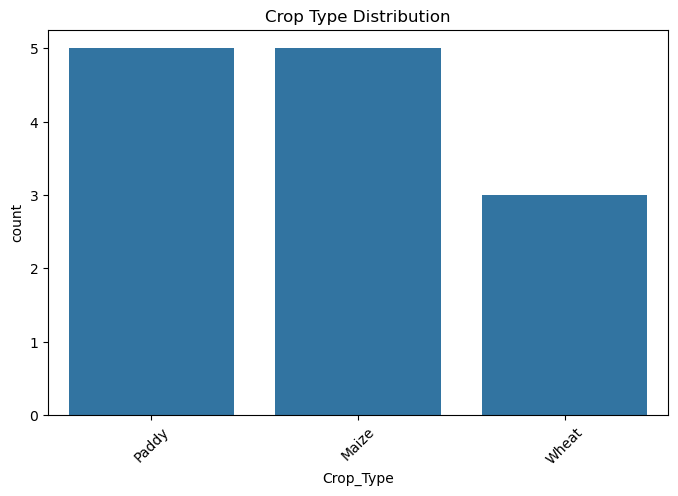

In [2]:
plt.figure(figsize=(8,5))
sns.countplot(x='Crop_Type', data=df)
plt.title("Crop Type Distribution")
plt.xticks(rotation=45)
plt.show()

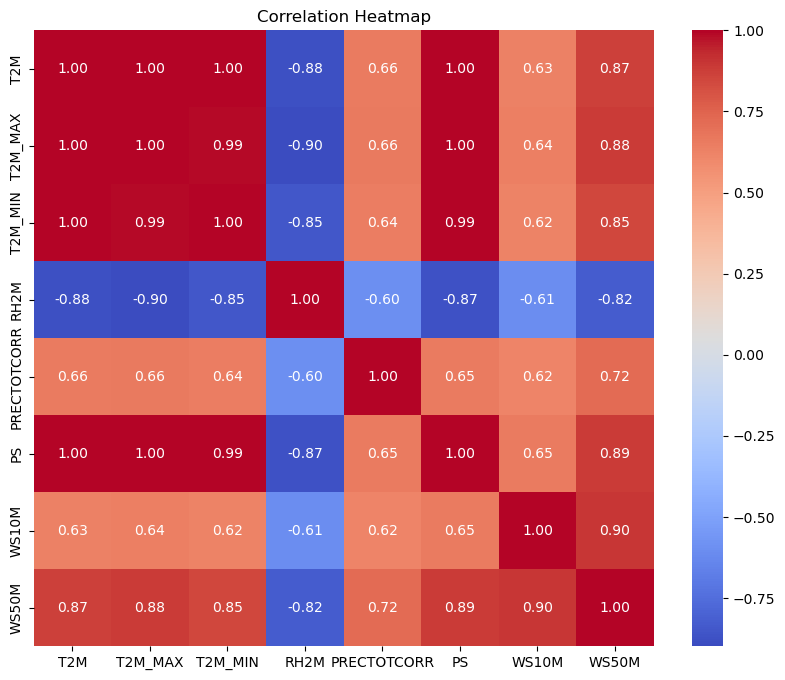

In [3]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

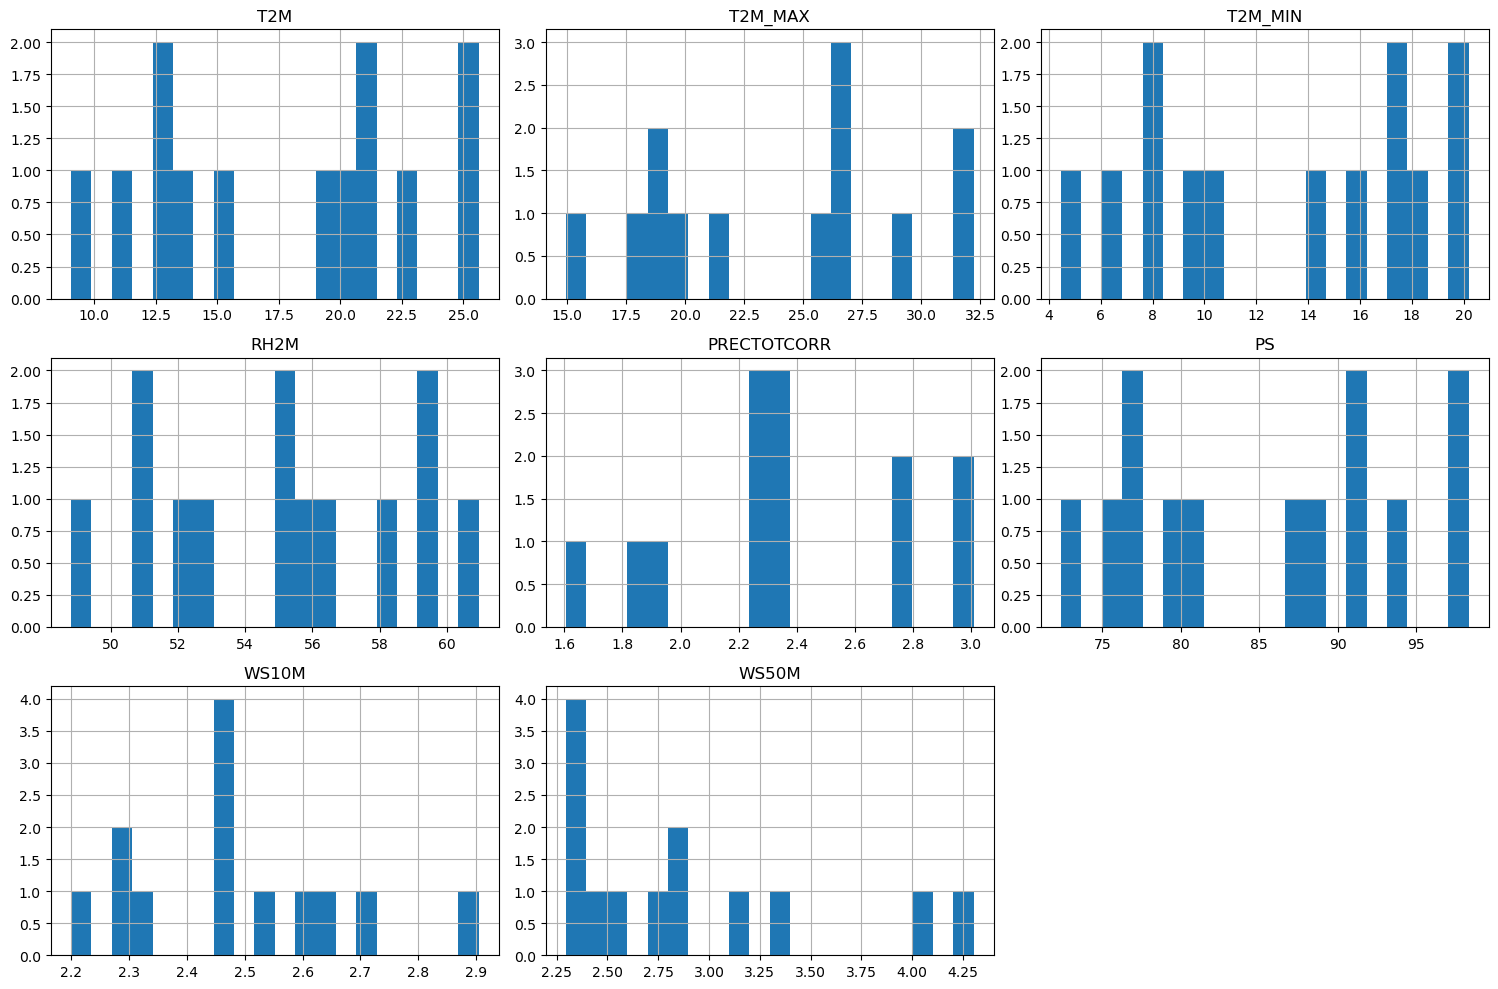

In [4]:
climate_features = [
    'T2M',
    'T2M_MAX',
    'T2M_MIN',
    'RH2M',
    'PRECTOTCORR',
    'PS',
    'WS10M',
    'WS50M'
]

df[climate_features].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

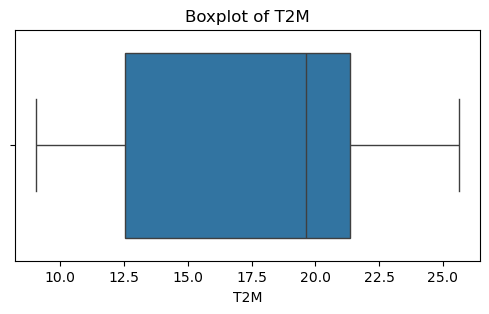

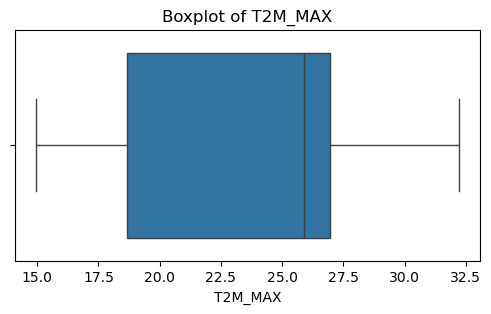

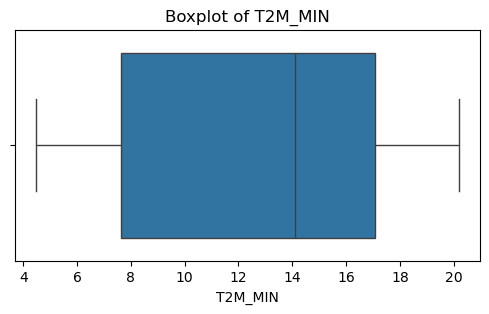

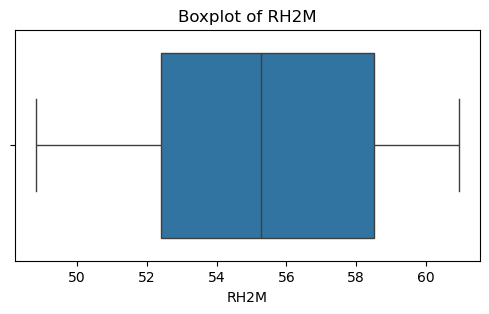

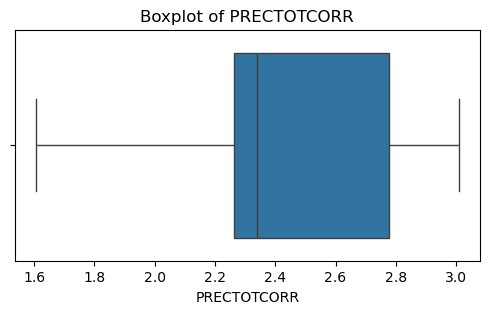

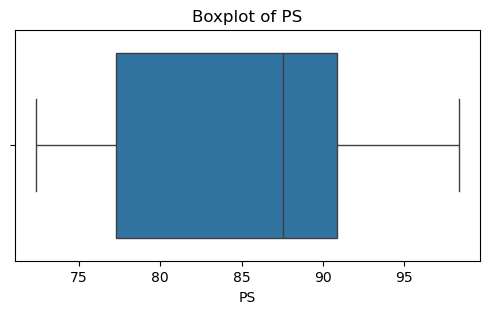

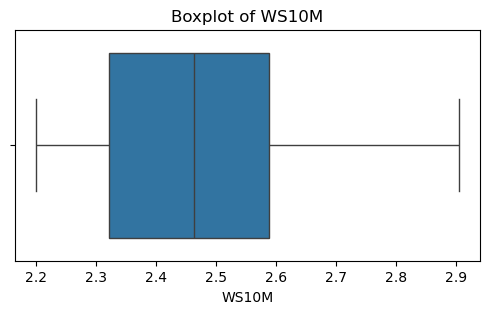

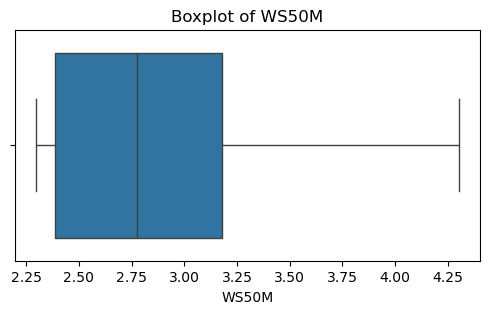

In [5]:
for col in climate_features:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

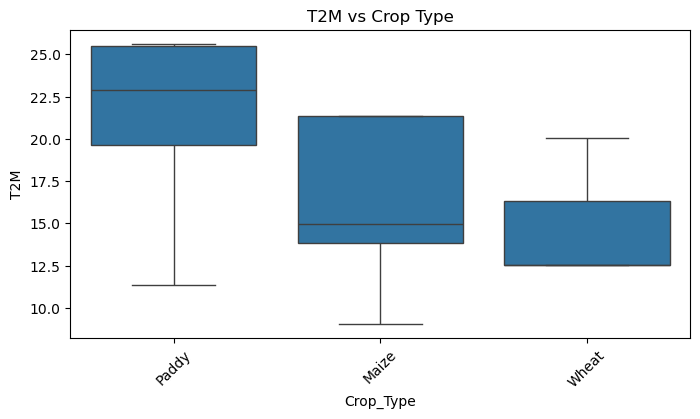

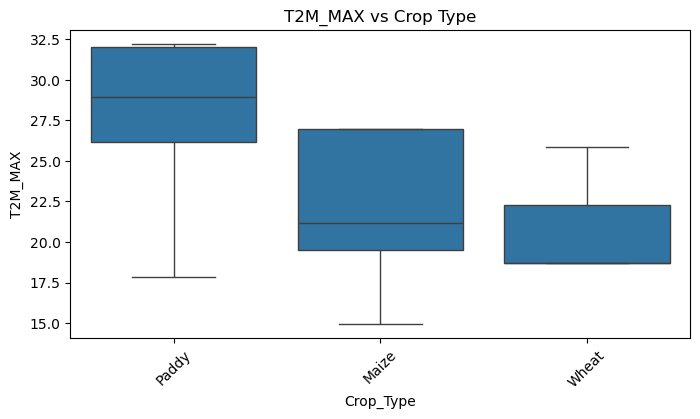

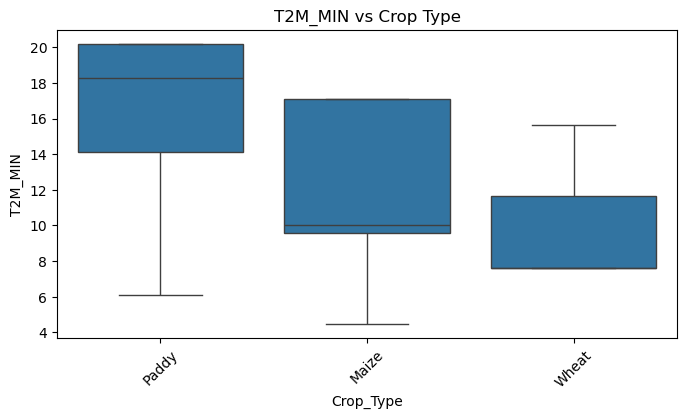

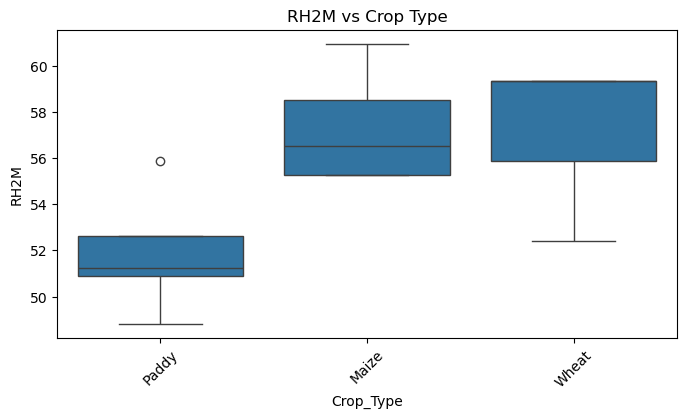

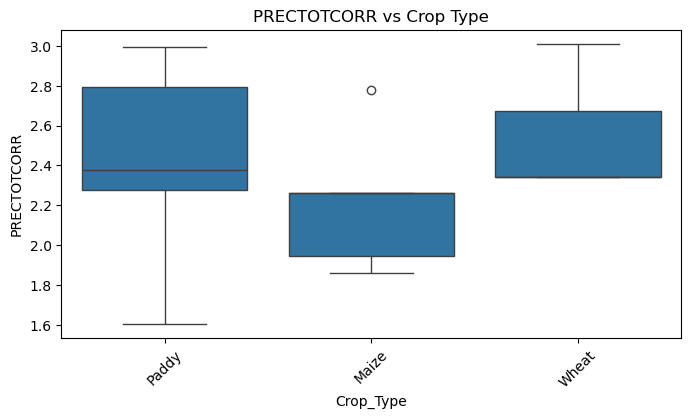

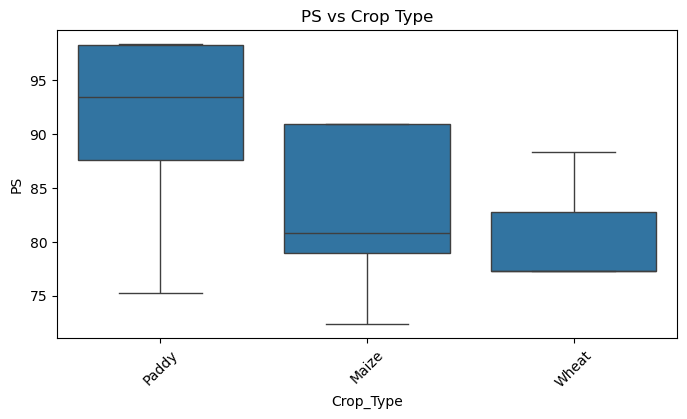

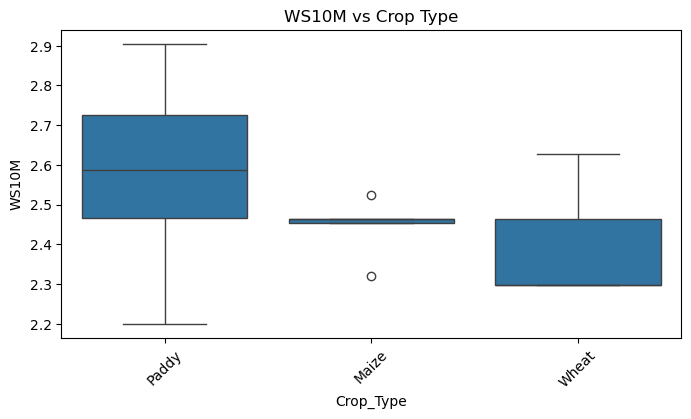

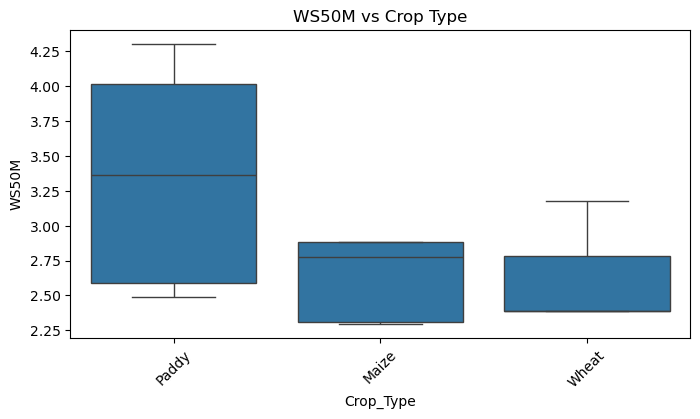

In [6]:
for col in climate_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x='Crop_Type',
        y=col,
        data=df
    )

    plt.title(f"{col} vs Crop Type")

    plt.xticks(rotation=45)

    plt.show()

In [7]:
df["Temp_Range"] = (
    df["T2M_MAX"] -
    df["T2M_MIN"]
)

In [8]:
df["Wind_Diff"] = (
    df["WS50M"] -
    df["WS10M"]
)

In [9]:
df["Moisture_Index"] = (
    df["PRECTOTCORR"] *
    df["RH2M"]
)

In [10]:
df["Heat_Humidity_Index"] = (
    df["T2M"] *
    df["RH2M"]
)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Crop_Label"] = le.fit_transform(
    df["Crop_Type"]
)

print(dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
))

{'Maize': np.int64(0), 'Paddy': np.int64(1), 'Wheat': np.int64(2)}


In [12]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(
    ["DISTRICT",
     "Crop_Type",
     "Crop_Label"],
    axis=1
)

y = df["Crop_Label"]

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
8            Temp_Range    0.166788
3                  RH2M    0.124760
6                 WS10M    0.112078
4           PRECTOTCORR    0.094925
1               T2M_MAX    0.076144
7                 WS50M    0.074697
10       Moisture_Index    0.074112
9             Wind_Diff    0.070642
2               T2M_MIN    0.067716
5                    PS    0.049952
11  Heat_Humidity_Index    0.046022
0                   T2M    0.042164


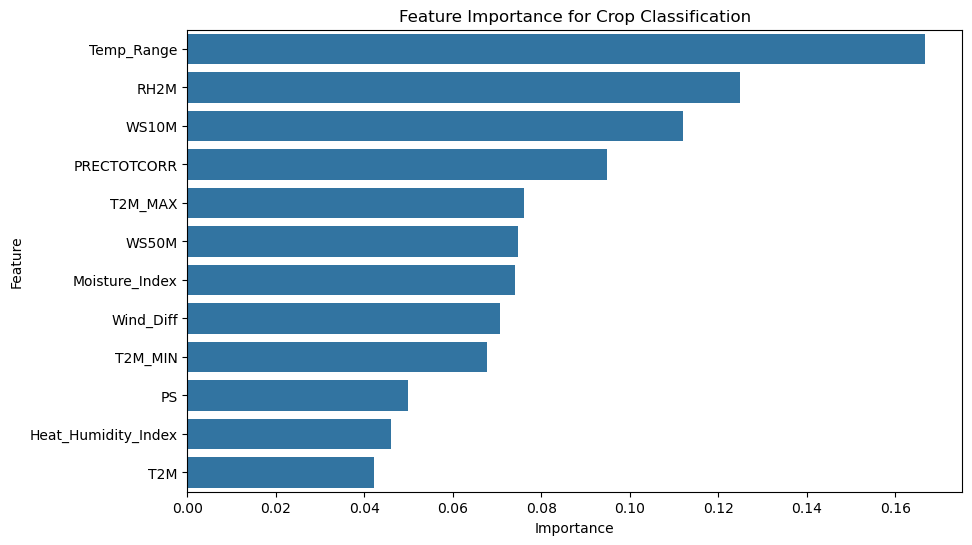

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Feature Importance for Crop Classification"
)

plt.show()

In [14]:
df.to_csv(
    "crop_classification_final_dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.
